<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/Broadband_Bar_Graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

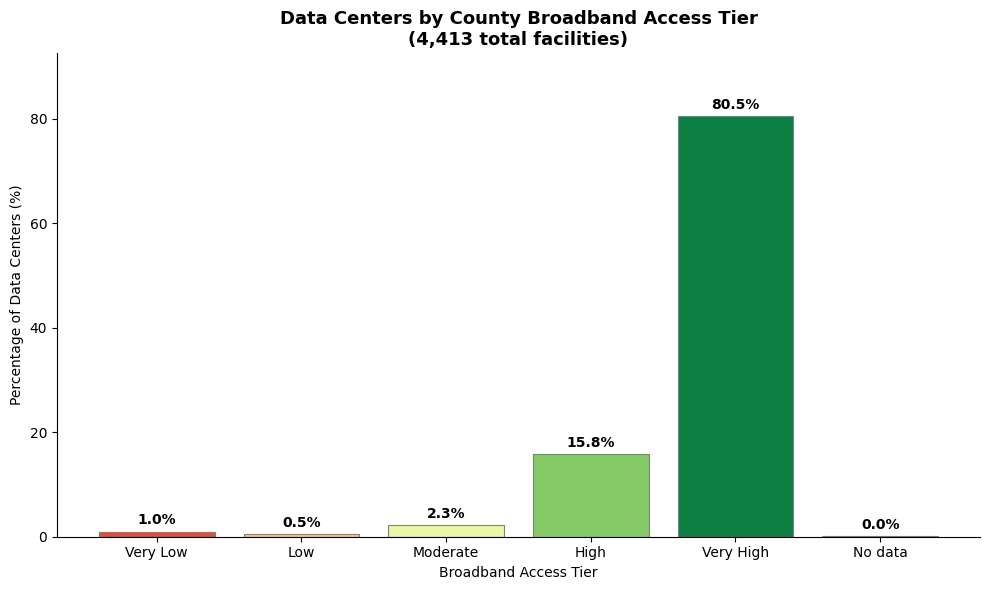

In [2]:
# Run once
# !pip install numpy pandas matplotlib openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Load & clean county-level broadband access data ----
file = "/content/2025 County Health Rankings Data - v4.xlsx"

excel_data = pd.read_excel(
    file,
    sheet_name="Select Measure Data",
    header=1
)

broad_access = excel_data[[
    "FIPS",
    "State",
    "County",
    "% Households with Broadband Access"
]].copy()

# Keep county rows only
broad_access = broad_access[broad_access["County"].notna()].copy()

broad_access["FIPS"] = broad_access["FIPS"].astype(int).astype(str).str.zfill(5)

broad_access["% Households with Broadband Access"] = pd.to_numeric(
    broad_access["% Households with Broadband Access"],
    errors="coerce"
)

# ---- Load data center / facility locations ----
facilities_file = "/content/facilities_final_complete.xlsx"

facilities = pd.read_excel(
    facilities_file,
    sheet_name="facilities_final_complete"
)

# Clean fips the same way as the county data so they can be matched
facilities["fips"] = facilities["fips"].astype(int).astype(str).str.zfill(5)

total_facility_count = len(facilities)

# ---- Build the same 5-tier broadband scale used on the map ----
# (2nd-98th percentile range split into 5 equal-width bins)
broadband_values = broad_access["% Households with Broadband Access"].dropna()
vmin = broadband_values.quantile(0.02)
vmax = broadband_values.quantile(0.98)
bins = np.linspace(vmin, vmax, 6)

broad_access["broadband_bin"] = pd.cut(
    broad_access["% Households with Broadband Access"],
    bins=bins,
    labels=False,
    include_lowest=True
)

# Clamp out-of-range values into the first/last tier
broad_access.loc[broad_access["% Households with Broadband Access"] < vmin, "broadband_bin"] = 0
broad_access.loc[broad_access["% Households with Broadband Access"] > vmax, "broadband_bin"] = 4

# ---- Match each facility to its county's broadband tier ----
facility_tiers = facilities.merge(
    broad_access[["FIPS", "broadband_bin"]],
    left_on="fips",
    right_on="FIPS",
    how="left"
)

# Broadband access tier names & colors, low -> high (same as map legend).
# Unlike the other maps, high here is good, so this stays
# red -> yellow -> green instead of yellow -> dark red.
tier_names = ["Very Low", "Low", "Moderate", "High", "Very High"]
tier_colors = plt.cm.RdYlGn(np.linspace(0.15, 0.95, 5))
missing_color = "#D9D9D9"

# Count data centers in each tier
counts = [(facility_tiers["broadband_bin"] == i).sum() for i in range(5)]
no_data_count = facility_tiers["broadband_bin"].isna().sum()

labels = tier_names + ["No data"]
values = counts + [no_data_count]
colors = list(tier_colors) + [missing_color]

# Convert counts to a percentage of all facilities
percentages = [v / total_facility_count * 100 for v in values]

# ---- Plot ----
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    labels,
    percentages,
    color=colors,
    edgecolor="#7f7f7f",
    linewidth=0.8
)

# Percentage label above each bar
for bar, pct in zip(bars, percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(percentages) * 0.01,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    f"Data Centers by County Broadband Access Tier\n({total_facility_count:,} total facilities)",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Broadband Access Tier")
ax.set_ylabel("Percentage of Data Centers (%)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, max(percentages) * 1.15)

plt.tight_layout()
plt.show()